In [52]:
%matplotlib inline

import math

import torch
from torch import nn
from d2l import torch as d2l

In [53]:
# 2D Optimization Helper

from collections.abc import Callable

Gradient2D = Callable[
    [float, float],
    tuple[float, float],
]

Trainer2D = Callable[
    [
        float,
        float,
        float,
        float,
        Gradient2D,
    ],
    tuple[
        float,
        float,
        float,
        float,
    ],
]

def train_2d(
    trainer: Trainer2D,
    gradient: Gradient2D,
    num_steps: int = 20,
) -> list[tuple[float, float]]:
    
    x1 = -5.0
    x2 = -2.0
    
    # Adagrad의 Squared Gradient accumulator
    accumulator1 = 0.0
    accumulator2 = 0.0
    
    results = [
        (x1, x2)
    ]
    
    for _ in range(num_steps):
        (
            x1,
            x2,
            accumulator1,
            accumulator2,
        ) = trainer(
            x1,
            x2,
            accumulator1,
            accumulator2,
            gradient,
        )
        
        results.append(
            (x1, x2)
        )
        
    print(
        f"step {num_steps}, "
        f"x1: {x1:f}, "
        f"x2: {x2:f}"
    )

    return results        

In [54]:
# 2D Optimization Trace

def show_trace_2d(
    objective: Callable[
        [torch.Tensor, torch.Tensor],
        torch.Tensor,
    ],
    results: list[tuple[float, float]],
) -> None:
    points = torch.tensor(
        results,
        dtype=torch.float32,
    )

    x1_grid, x2_grid = torch.meshgrid(
        torch.arange(
            -5.5,
            1.0,
            0.1,
        ),
        torch.arange(
            -3.0,
            3.0,
            0.1,
        ),
        indexing="ij",
    )

    d2l.set_figsize()

    d2l.plt.plot(
        points[:, 0],
        points[:, 1],
        "-o",
        color="#E45756",
    )

    d2l.plt.contour(
        x1_grid,
        x2_grid,
        objective(
            x1_grid,
            x2_grid,
        ),
        colors="#4C78A8",
    )

    d2l.plt.xlabel("x1")
    d2l.plt.ylabel("x2")

In [55]:
# Objective Function, Gradient, Adagrad Update

def objective_2d(
    x1: torch.Tensor,
    x2: torch.Tensor,
) -> torch.Tensor:
    return (
        0.1 * x1.pow(2)
        + 2 * x2.pow(2)
    )
    
def objective_gradient_2d(
    x1: float,
    x2: float,
) -> tuple[float, float]:
    return (
        0.2 * x1,
        4 * x2,
    )
    
    
learning_rate = 0.4


def adagrad_2d(
    x1: float,
    x2: float,
    accumulator1: float,
    accumulator2: float,
    gradient: Gradient2D,
) -> tuple[
    float,
    float,
    float,
    float,
]:
    epsilon = 1e-6
    
    gradient1, gradient2 = gradient(
        x1,
        x2,
    )
    
    # s_t = s_(t-1) + g_t²
    accumulator1 += gradient1**2
    accumulator2 += gradient2**2
    
    # x_t = x_(t-1) - {eta / sqrt(s_t + epsilon)} * g_t
    x1 -= (
        learning_rate
        / math.sqrt(
            accumulator1 + epsilon
        )
        * gradient1
    )
    
    x2 -= (
        learning_rate
        / math.sqrt(
            accumulator2 + epsilon
        )
        * gradient2
    )
    
    return (
        x1,
        x2,
        accumulator1,
        accumulator2,
    )

step 20, x1: -2.382563, x2: -0.158591


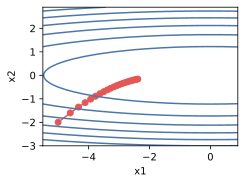

In [56]:
# Adagrad with Learning Rate: 0.4

learning_rate = 0.4

adagrad_results_small_lr = train_2d(
    trainer=adagrad_2d,
    gradient=objective_gradient_2d,
)

show_trace_2d(
    objective_2d,
    adagrad_results_small_lr,
)

step 20, x1: -0.002295, x2: -0.000000


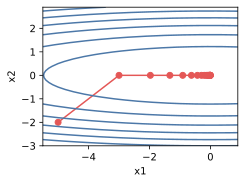

In [57]:
# Adagrad with Learning Rate: 2.0

learning_rate = 2.0

adagrad_results_large_lr = train_2d(
    trainer=adagrad_2d,
    gradient=objective_gradient_2d,
)

show_trace_2d(
    objective_2d,
    adagrad_results_large_lr,
)